In [7]:
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('cleaned_lalpurja_house_after_cleaning.csv')

In [4]:
pd.set_option('display.max_columns',None)

In [5]:
df.sample(4)

,district,property_type,property_face,road_type,negotiable,furnishing,property_area,date_posted,views,municipality,ward_no,neighborhood,total_price,land_size_aana,built_up_sqft,house_age,road_width_feet,hospital_m,airport_m,pharmacy_m,bhatbhateni_m,school_m,college_m,public_transport_m,police_station_m,pashupatinath_m,boudhanath_m,ring_road_m
72,Kathmandu,Residential,South-East,High Access,Yes,Semi Furnished,3 Aana,2025 September 2,318.0,Budhanilkantha,9.0,Mandikatar,26000000.0,3.00,1026.75,4.0,13.0,200.0,5000.0,200.0,200.0,200.0,400.0,300.0,200.0,6000.0,5000.0,300.0
855,Kathmandu,Semi-commercial,East,High Access,Yes,Unfurnished,5.5 Aana,2025 January 15,334.0,Kathmandu,32.0,Koteshwor,45000000.0,5.50,1197.88,15.0,26.0,300.0,1000.0,10.0,1000.0,100.0,100.0,100.0,260.0,2000.0,3000.0,100.0
360,Kathmandu,Residential,West,High Access,Yes,Unfurnished,6 Aana,2025 June 20,465.0,Kathmandu,4.0,Baluwatar,72500000.0,6.00,1369.00,22.0,15.0,400.0,4220.0,70.4,590.0,160.0,180.0,50.0,550.0,7800.0,8420.0,50.0
669,Kathmandu,Residential,East,High Access,Yes,Full Furnished,3.75 Aana,2025 March 11,467.0,Nagarjun,1.0,Raniban,40000000.0,3.75,1026.75,4.0,18.0,3000.0,8000.0,500.0,3000.0,500.0,1000.0,100.0,1000.0,7500.0,8000.0,2000.0


In [6]:
df_lph=df.copy()

In [8]:


# ─────────────────────────────────────────
# STEP 1 — BASIC STATS
# ─────────────────────────────────────────
print("=== Basic Stats ===")
print(f"Shape: {df_lph.shape}")

print("\n=== total_price stats ===")
print(df_lph['total_price'].describe())

print("\n=== land_size_aana stats ===")
print(df_lph['land_size_aana'].describe())

print("\n=== built_up_sqft stats ===")
print(df_lph['built_up_sqft'].describe())

print("\n=== house_age stats ===")
print(df_lph['house_age'].describe())

print("\n=== District distribution ===")
print(df_lph['district'].value_counts())

print("\n=== property_type distribution ===")
print(df_lph['property_type'].value_counts())

print("\n=== furnishing distribution ===")
print(df_lph['furnishing'].value_counts())

print("\n=== Price by district ===")
print(df_lph.groupby('district')['total_price'].median().sort_values(ascending=False))

print("\n=== Price by property_type ===")
print(df_lph.groupby('property_type')['total_price'].median().sort_values(ascending=False))

print("\n=== Correlation with total_price ===")
num_cols = ['total_price', 'land_size_aana', 'built_up_sqft', 'house_age',
            'road_width_feet', 'hospital_m', 'airport_m', 'school_m',
            'ring_road_m', 'public_transport_m', 'bhatbhateni_m']
print(df_lph[num_cols].corr()['total_price'].sort_values(ascending=False))

=== Basic Stats ===
Shape: (2190, 28)

=== total_price stats ===
count    2.190000e+03
mean     4.317799e+07
std      3.233398e+07
min      1.000000e+07
25%      2.600000e+07
50%      3.500000e+07
75%      4.800000e+07
max      3.500000e+08
Name: total_price, dtype: float64

=== land_size_aana stats ===
count    2190.000000
mean        5.130866
std         3.912851
min         1.000000
25%         3.250000
50%         4.000000
75%         5.500000
max        50.000000
Name: land_size_aana, dtype: float64

=== built_up_sqft stats ===
count     2190.000000
mean      1461.127303
std        835.169869
min        119.220000
25%       1026.750000
50%       1197.880000
75%       1711.250000
max      10000.000000
Name: built_up_sqft, dtype: float64

=== house_age stats ===
count    2190.000000
mean        8.092009
std         8.555591
min         0.000000
25%         2.000000
50%         5.000000
75%        11.000000
max        60.000000
Name: house_age, dtype: float64

=== District distributi

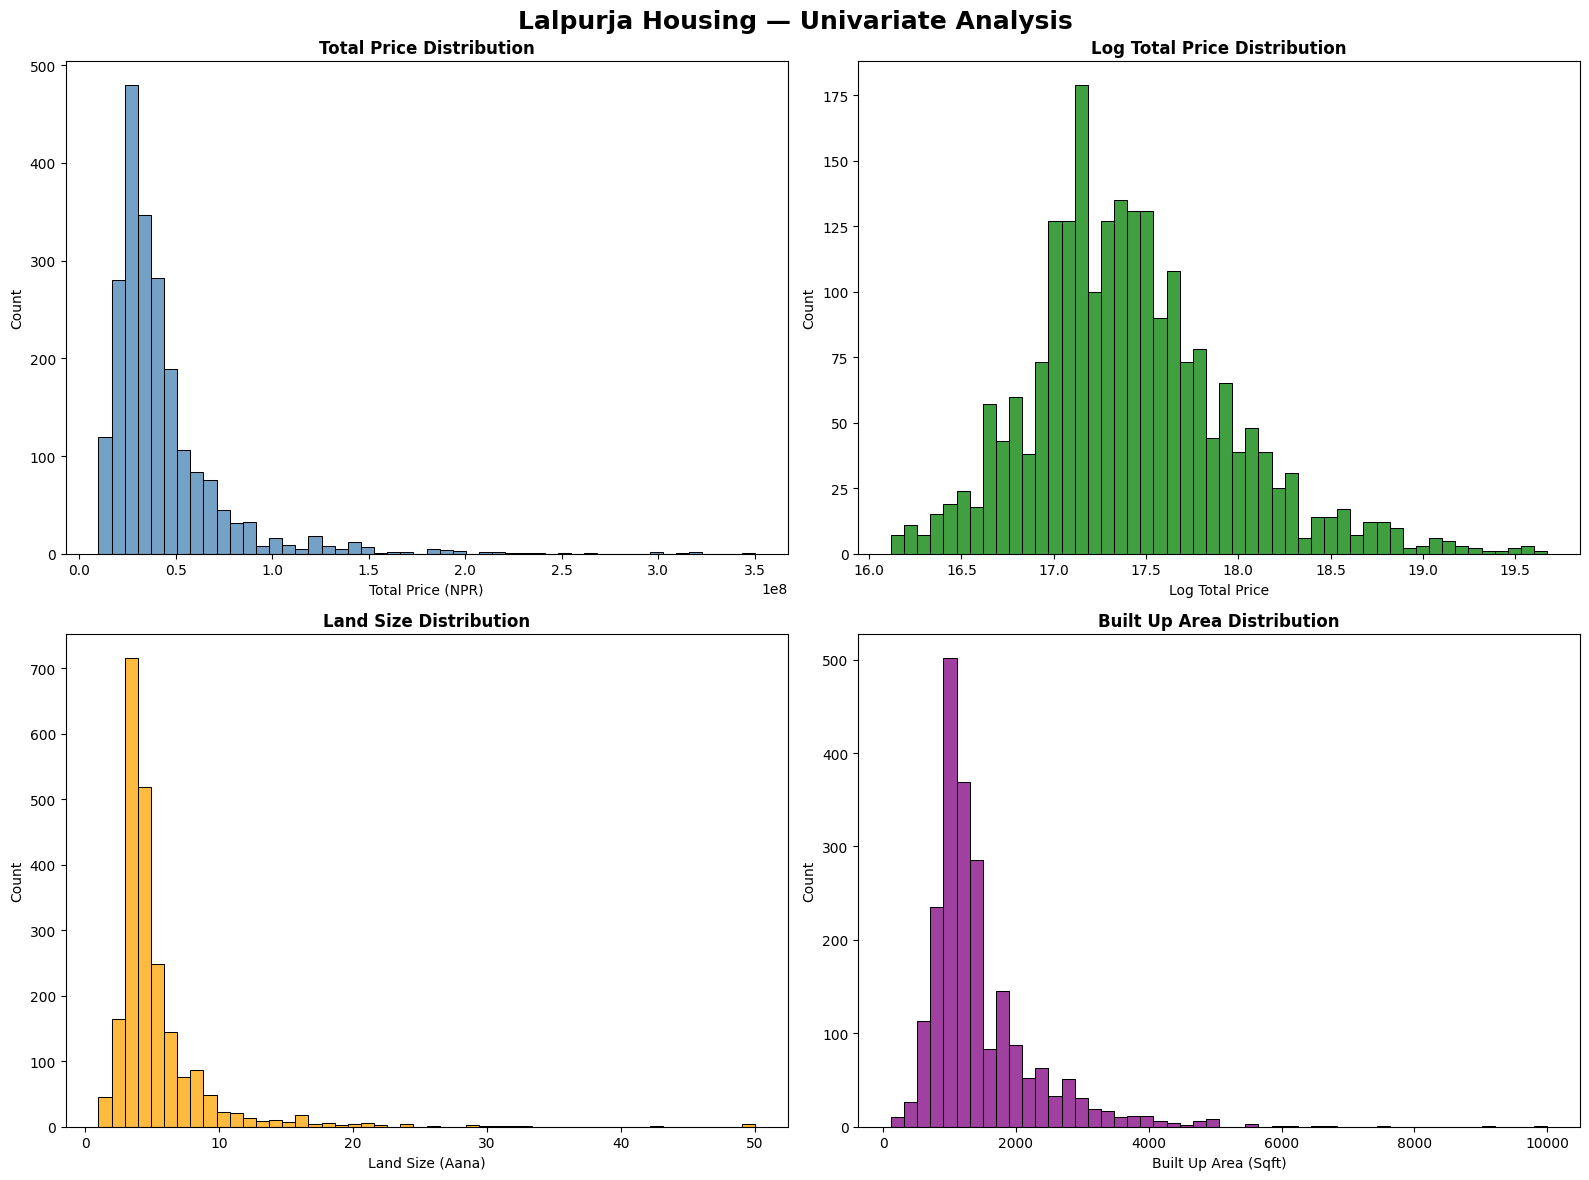

=== Skewness ===
total_price skewness:    3.736
log price skewness:      0.695
land_size_aana skewness: 5.177
built_up_sqft skewness:  2.817
house_age skewness:      1.789


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Lalpurja Housing — Univariate Analysis', fontsize=18, fontweight='bold')

# Plot 1 — total_price distribution
# Why: Check if price is skewed — determines if log transform needed
sns.histplot(df_lph['total_price'], bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Price Distribution', fontweight='bold')
axes[0,0].set_xlabel('Total Price (NPR)')

# Plot 2 — log total_price distribution
# Why: Log transform often normalizes skewed price data
sns.histplot(np.log1p(df_lph['total_price']), bins=50, ax=axes[0,1], color='green')
axes[0,1].set_title('Log Total Price Distribution', fontweight='bold')
axes[0,1].set_xlabel('Log Total Price')

# Plot 3 — land_size_aana distribution
# Why: Strongest predictor — understand its distribution
sns.histplot(df_lph['land_size_aana'], bins=50, ax=axes[1,0], color='orange')
axes[1,0].set_title('Land Size Distribution', fontweight='bold')
axes[1,0].set_xlabel('Land Size (Aana)')

# Plot 4 — built_up_sqft distribution
# Why: Second strongest predictor — check skewness
sns.histplot(df_lph['built_up_sqft'], bins=50, ax=axes[1,1], color='purple')
axes[1,1].set_title('Built Up Area Distribution', fontweight='bold')
axes[1,1].set_xlabel('Built Up Area (Sqft)')

plt.tight_layout()
plt.show()

print("=== Skewness ===")
print(f"total_price skewness:    {df_lph['total_price'].skew():.3f}")
print(f"log price skewness:      {np.log1p(df_lph['total_price']).skew():.3f}")
print(f"land_size_aana skewness: {df_lph['land_size_aana'].skew():.3f}")
print(f"built_up_sqft skewness:  {df_lph['built_up_sqft'].skew():.3f}")
print(f"house_age skewness:      {df_lph['house_age'].skew():.3f}")

C:\Users\DELL\AppData\Local\Temp\ipykernel_18836\3998180179.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lph, x='district', y='total_price',
C:\Users\DELL\AppData\Local\Temp\ipykernel_18836\3998180179.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lph, x='property_type', y='total_price',


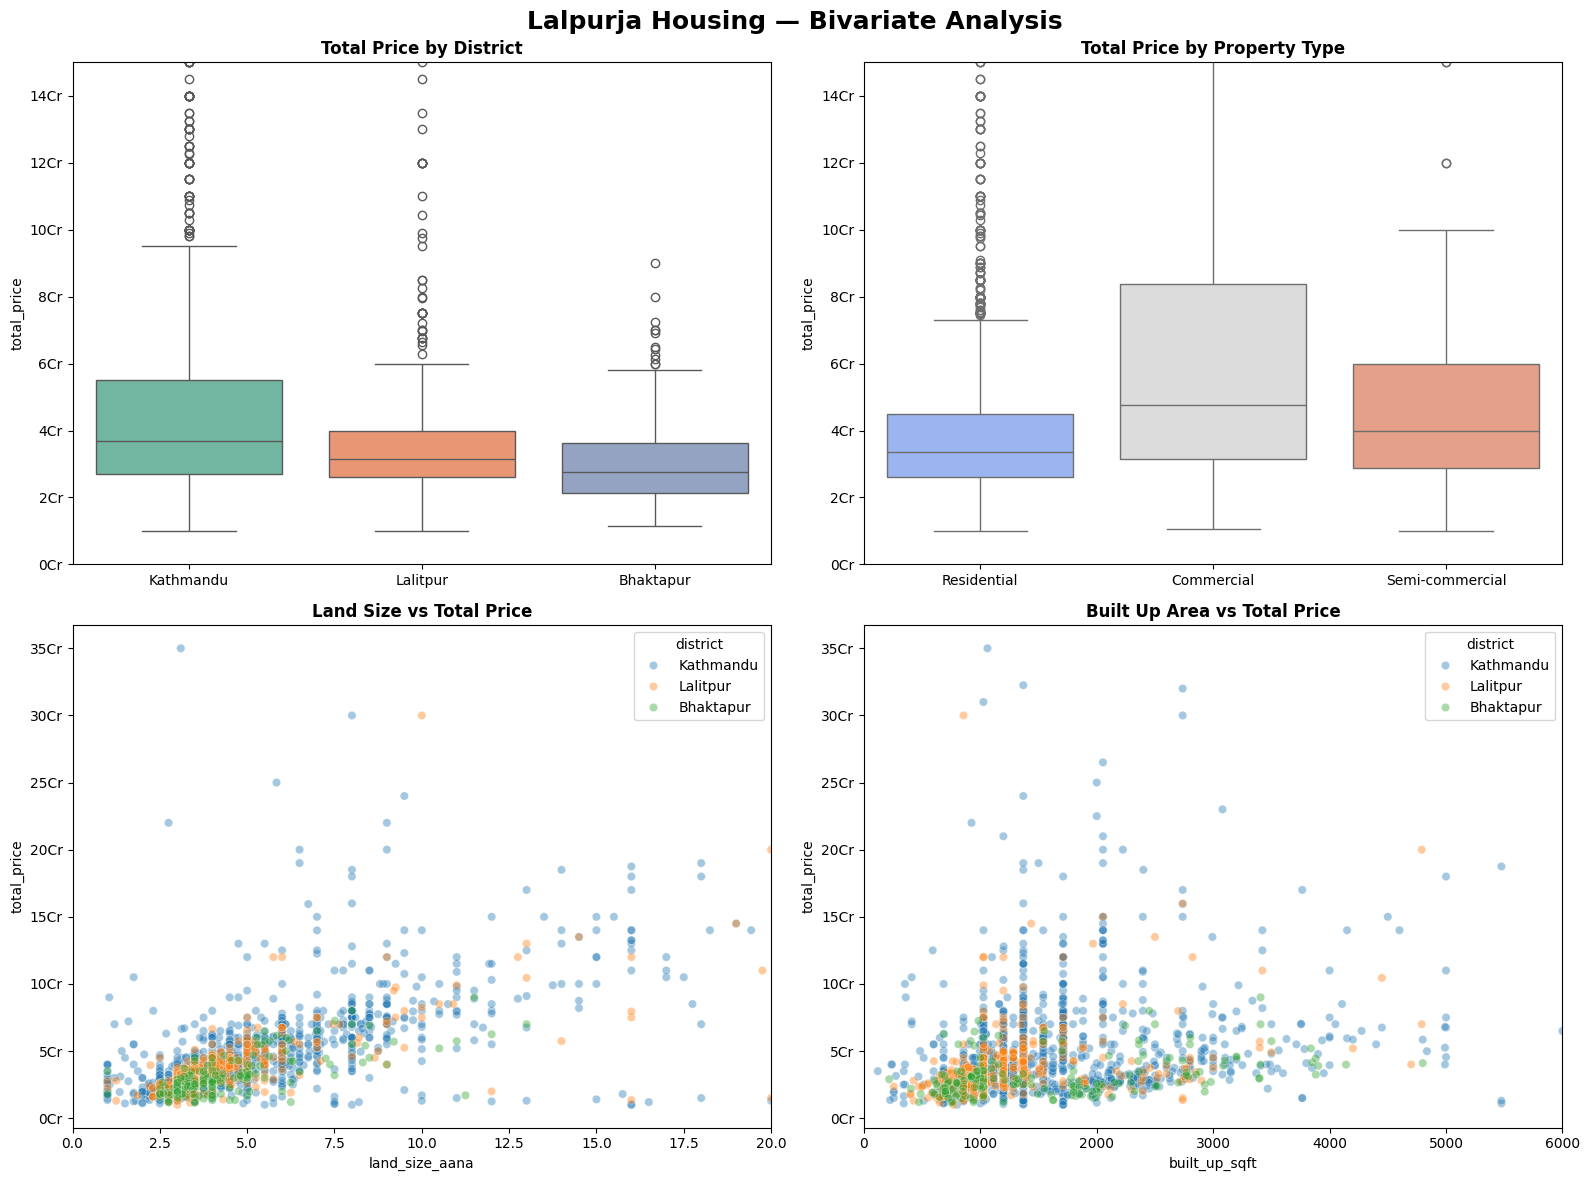

=== Price by District ===
district
Kathmandu    37000000.0
Lalitpur     31500000.0
Bhaktapur    27500000.0
Name: total_price, dtype: float64

=== Price by Property Type ===
property_type
Commercial         47750000.0
Semi-commercial    40000000.0
Residential        33500000.0
Name: total_price, dtype: float64

=== Price by Furnishing ===
furnishing
Full Furnished    43500000.0
Semi Furnished    33000000.0
Unfurnished       32750000.0
Name: total_price, dtype: float64

=== Price by Road Type ===
road_type
High Access    36000000.0
Low Access     29500000.0
Name: total_price, dtype: float64


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Lalpurja Housing — Bivariate Analysis', fontsize=18, fontweight='bold')

# Plot 1 — Price by district
# Why: Confirm price hierarchy across 3 districts
# and check spread within each district
sns.boxplot(data=df_lph, x='district', y='total_price',
            ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Total Price by District', fontweight='bold')
axes[0,0].set_ylim(0, 150000000)
axes[0,0].set_xlabel('')
axes[0,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

# Plot 2 — Price by property_type
# Why: Check commercial premium over residential
sns.boxplot(data=df_lph, x='property_type', y='total_price',
            ax=axes[0,1], palette='coolwarm')
axes[0,1].set_title('Total Price by Property Type', fontweight='bold')
axes[0,1].set_ylim(0, 150000000)
axes[0,1].set_xlabel('')
axes[0,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

# Plot 3 — Land size vs price
# Why: Strongest correlation (0.659) — visualize the relationship
sns.scatterplot(data=df_lph, x='land_size_aana', y='total_price',
                hue='district', ax=axes[1,0], alpha=0.4)
axes[1,0].set_title('Land Size vs Total Price', fontweight='bold')
axes[1,0].set_xlim(0, 20)
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

# Plot 4 — Built up area vs price
# Why: Second strongest correlation (0.304)
sns.scatterplot(data=df_lph, x='built_up_sqft', y='total_price',
                hue='district', ax=axes[1,1], alpha=0.4)
axes[1,1].set_title('Built Up Area vs Total Price', fontweight='bold')
axes[1,1].set_xlim(0, 6000)
axes[1,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

plt.tight_layout()
plt.show()

print("=== Price by District ===")
print(df_lph.groupby('district')['total_price']\
      .median().sort_values(ascending=False))

print("\n=== Price by Property Type ===")
print(df_lph.groupby('property_type')['total_price']\
      .median().sort_values(ascending=False))

print("\n=== Price by Furnishing ===")
print(df_lph.groupby('furnishing')['total_price']\
      .median().sort_values(ascending=False))

print("\n=== Price by Road Type ===")
print(df_lph.groupby('road_type')['total_price']\
      .median().sort_values(ascending=False))

C:\Users\DELL\AppData\Local\Temp\ipykernel_18836\370205004.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lph, x='furnishing', y='total_price',
C:\Users\DELL\AppData\Local\Temp\ipykernel_18836\370205004.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lph, x='road_type', y='total_price',


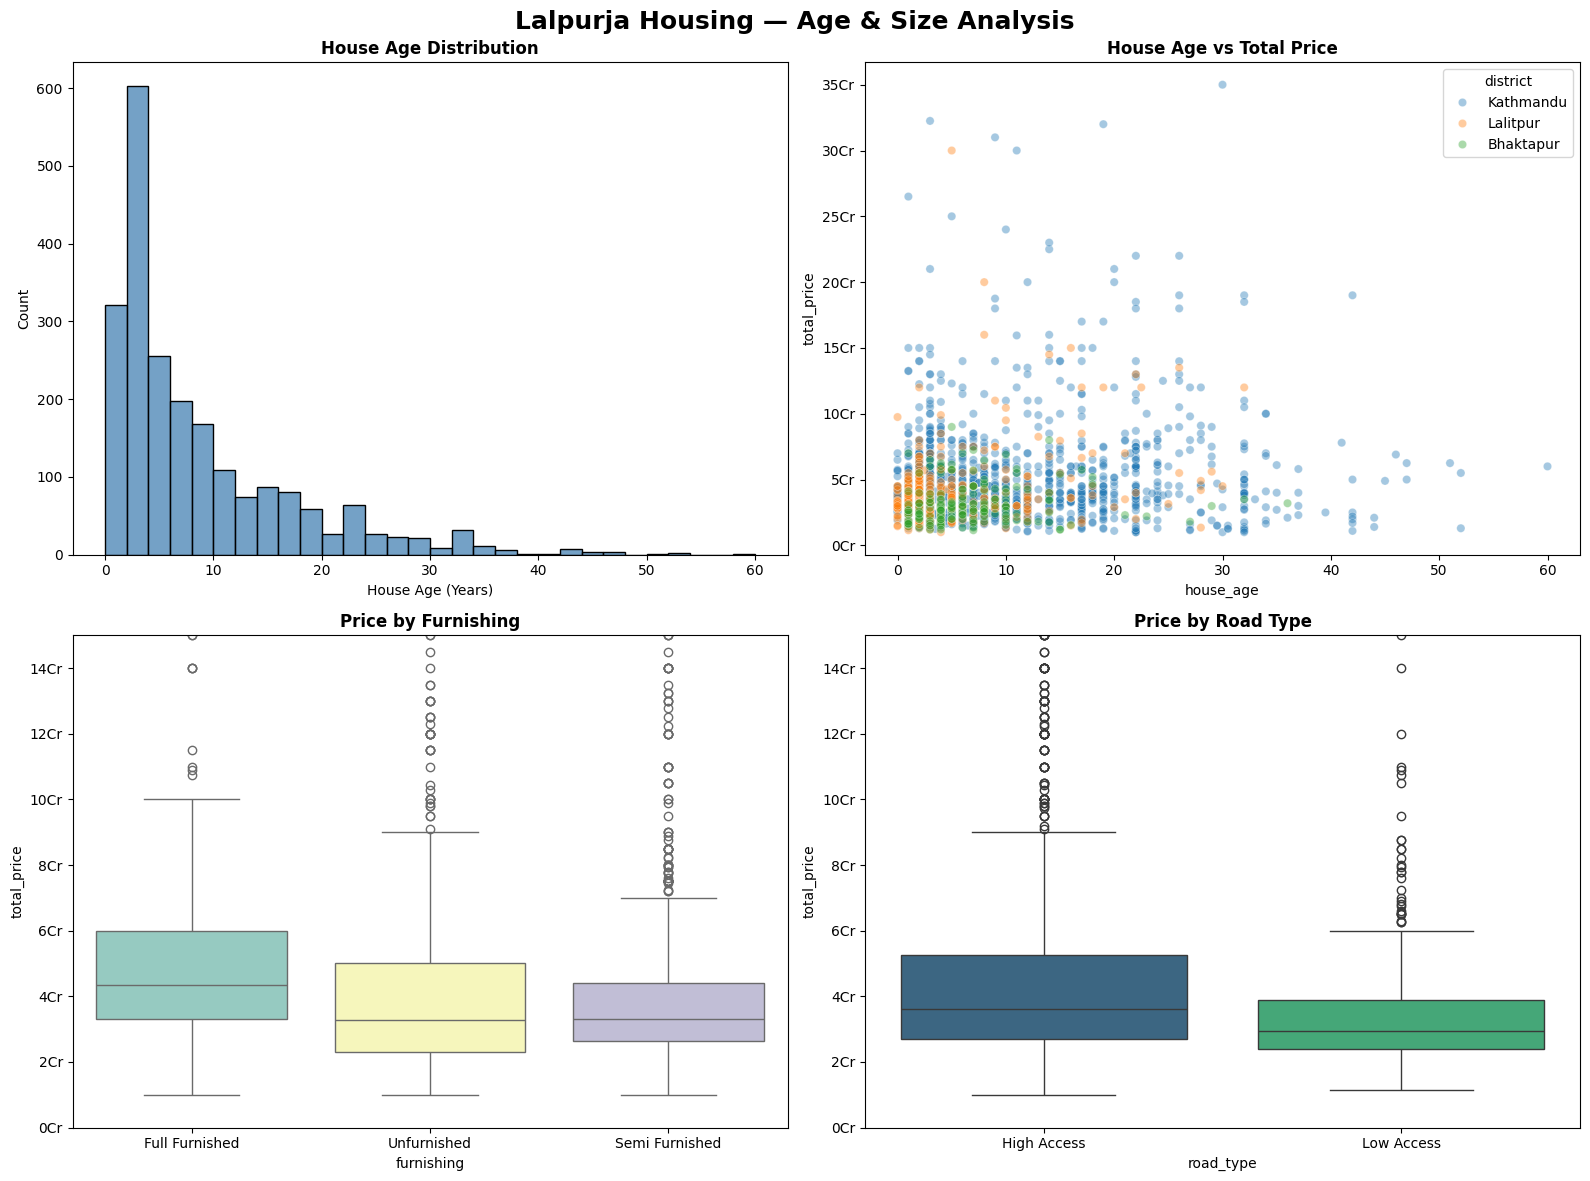

=== House Age bins ===
age_bin
0-2yr      32000000.0
3-5yr      35000000.0
6-10yr     33250000.0
11-20yr    39000000.0
20+yr      45050000.0
Name: total_price, dtype: float64

=== Built up area bins vs price ===
size_bin
tiny      23500000.0
small     32000000.0
medium    43250000.0
large     35000000.0
xlarge    55000000.0
Name: total_price, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_18836\370205004.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_lph.groupby('age_bin')['total_price'].median())
C:\Users\DELL\AppData\Local\Temp\ipykernel_18836\370205004.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_lph.groupby('size_bin')['total_price'].median())


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Lalpurja Housing — Age & Size Analysis', fontsize=18, fontweight='bold')

# Plot 1 — House age distribution
# Why: Understand the age spread — mostly new or mixed?
sns.histplot(df_lph['house_age'], bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('House Age Distribution', fontweight='bold')
axes[0,0].set_xlabel('House Age (Years)')

# Plot 2 — House age vs price
# Why: Positive correlation (0.189) is counterintuitive
# Visualize if older = more expensive pattern holds
sns.scatterplot(data=df_lph, x='house_age', y='total_price',
                hue='district', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('House Age vs Total Price', fontweight='bold')
axes[0,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

# Plot 3 — Price by furnishing
# Why: Full furnished showed 10.75M premium — visualize spread
sns.boxplot(data=df_lph, x='furnishing', y='total_price',
            ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Price by Furnishing', fontweight='bold')
axes[1,0].set_ylim(0, 150000000)
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

# Plot 4 — Price by road_type
# Why: 6.5M premium for High Access — confirm visually
sns.boxplot(data=df_lph, x='road_type', y='total_price',
            ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Price by Road Type', fontweight='bold')
axes[1,1].set_ylim(0, 150000000)
axes[1,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

plt.tight_layout()
plt.show()

print("=== House Age bins ===")
df_lph['age_bin'] = pd.cut(df_lph['house_age'],
                            bins=[0, 2, 5, 10, 20, 60],
                            labels=['0-2yr', '3-5yr', '6-10yr', '11-20yr', '20+yr'])
print(df_lph.groupby('age_bin')['total_price'].median())

print("\n=== Built up area bins vs price ===")
df_lph['size_bin'] = pd.cut(df_lph['built_up_sqft'],
                             bins=[0, 800, 1200, 1800, 3000, 10000],
                             labels=['tiny', 'small', 'medium', 'large', 'xlarge'])
print(df_lph.groupby('size_bin')['total_price'].median())

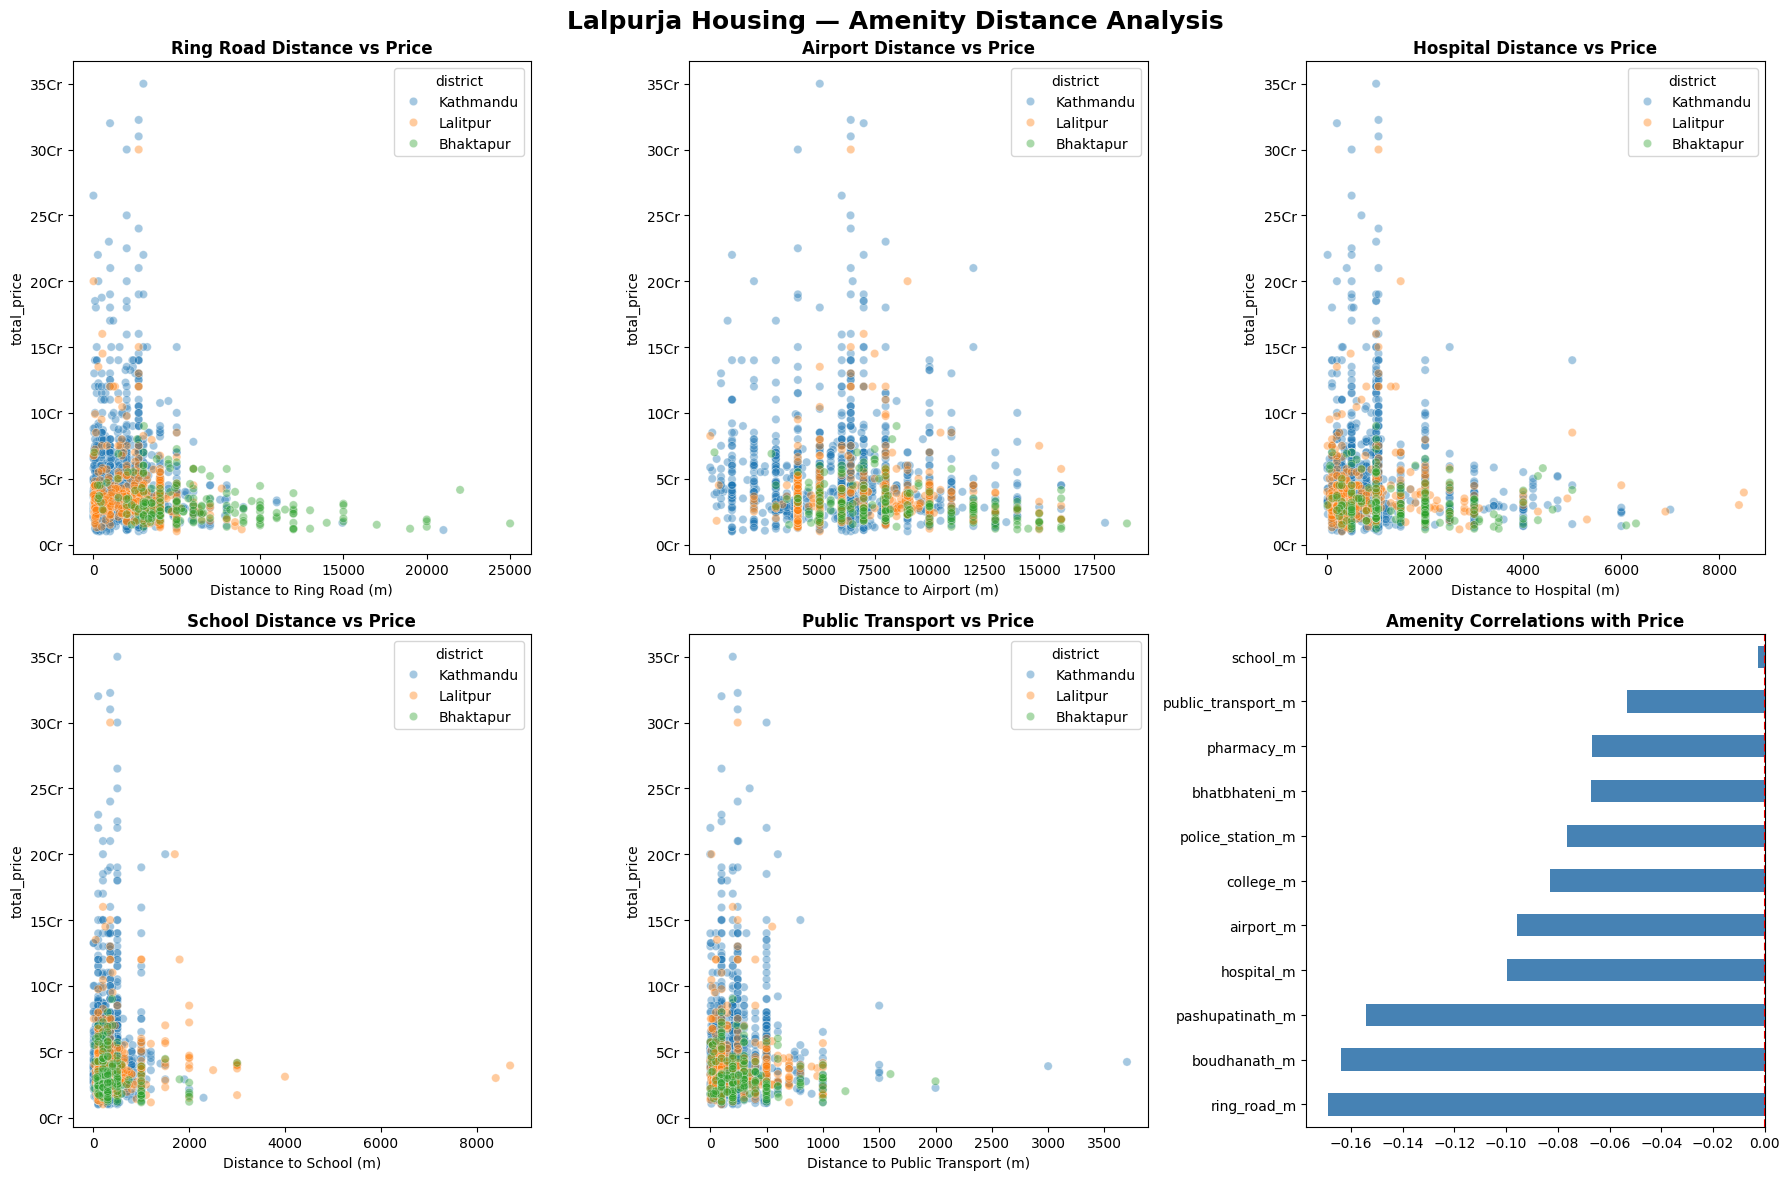

=== All amenity correlations ===
ring_road_m          -0.168837
boudhanath_m         -0.163781
pashupatinath_m      -0.154035
hospital_m           -0.099646
airport_m            -0.095952
college_m            -0.083098
police_station_m     -0.076311
bhatbhateni_m        -0.067110
pharmacy_m           -0.066917
public_transport_m   -0.053096
school_m             -0.002536
dtype: float64

=== Average distances by district ===
           hospital_m  airport_m  pharmacy_m  bhatbhateni_m  school_m  \
district                                                                
Bhaktapur      1400.0     8000.0       200.0         3000.0     300.0   
Kathmandu      1000.0     6411.0       200.0         2000.0     300.0   
Lalitpur        400.0     6000.0       100.0          600.0     200.0   

           college_m  public_transport_m  police_station_m  pashupatinath_m  \
district                                                                      
Bhaktapur      676.0               232.0        

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Lalpurja Housing — Amenity Distance Analysis', fontsize=18, fontweight='bold')

# Plot 1 — Ring road vs price
# Why: Strongest amenity correlation (-0.169)
sns.scatterplot(data=df_lph, x='ring_road_m', y='total_price',
                hue='district', ax=axes[0,0], alpha=0.4)
axes[0,0].set_title('Ring Road Distance vs Price', fontweight='bold')
axes[0,0].set_xlabel('Distance to Ring Road (m)')
axes[0,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

# Plot 2 — Airport vs price
# Why: Second strongest amenity correlation (-0.096)
sns.scatterplot(data=df_lph, x='airport_m', y='total_price',
                hue='district', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('Airport Distance vs Price', fontweight='bold')
axes[0,1].set_xlabel('Distance to Airport (m)')
axes[0,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

# Plot 3 — Hospital vs price
# Why: Check if healthcare access affects house price
sns.scatterplot(data=df_lph, x='hospital_m', y='total_price',
                hue='district', ax=axes[0,2], alpha=0.4)
axes[0,2].set_title('Hospital Distance vs Price', fontweight='bold')
axes[0,2].set_xlabel('Distance to Hospital (m)')
axes[0,2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

# Plot 4 — School vs price
# Why: School proximity important for families
sns.scatterplot(data=df_lph, x='school_m', y='total_price',
                hue='district', ax=axes[1,0], alpha=0.4)
axes[1,0].set_title('School Distance vs Price', fontweight='bold')
axes[1,0].set_xlabel('Distance to School (m)')
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

# Plot 5 — Public transport vs price
# Why: Commute convenience affects house value
sns.scatterplot(data=df_lph, x='public_transport_m', y='total_price',
                hue='district', ax=axes[1,1], alpha=0.4)
axes[1,1].set_title('Public Transport vs Price', fontweight='bold')
axes[1,1].set_xlabel('Distance to Public Transport (m)')
axes[1,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10000000:.0f}Cr'))

# Plot 6 — Correlation bar chart of all amenities
# Why: Visual summary of which amenity has strongest price impact
amenity_cols = ['hospital_m', 'airport_m', 'pharmacy_m', 'bhatbhateni_m',
                'school_m', 'college_m', 'public_transport_m',
                'police_station_m', 'pashupatinath_m', 'boudhanath_m', 'ring_road_m']
corrs = df_lph[amenity_cols].corrwith(df_lph['total_price']).sort_values()
corrs.plot(kind='barh', ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Amenity Correlations with Price', fontweight='bold')
axes[1,2].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print("=== All amenity correlations ===")
print(corrs.sort_values())

print("\n=== Average distances by district ===")
print(df_lph.groupby('district')[amenity_cols].median().round(0))

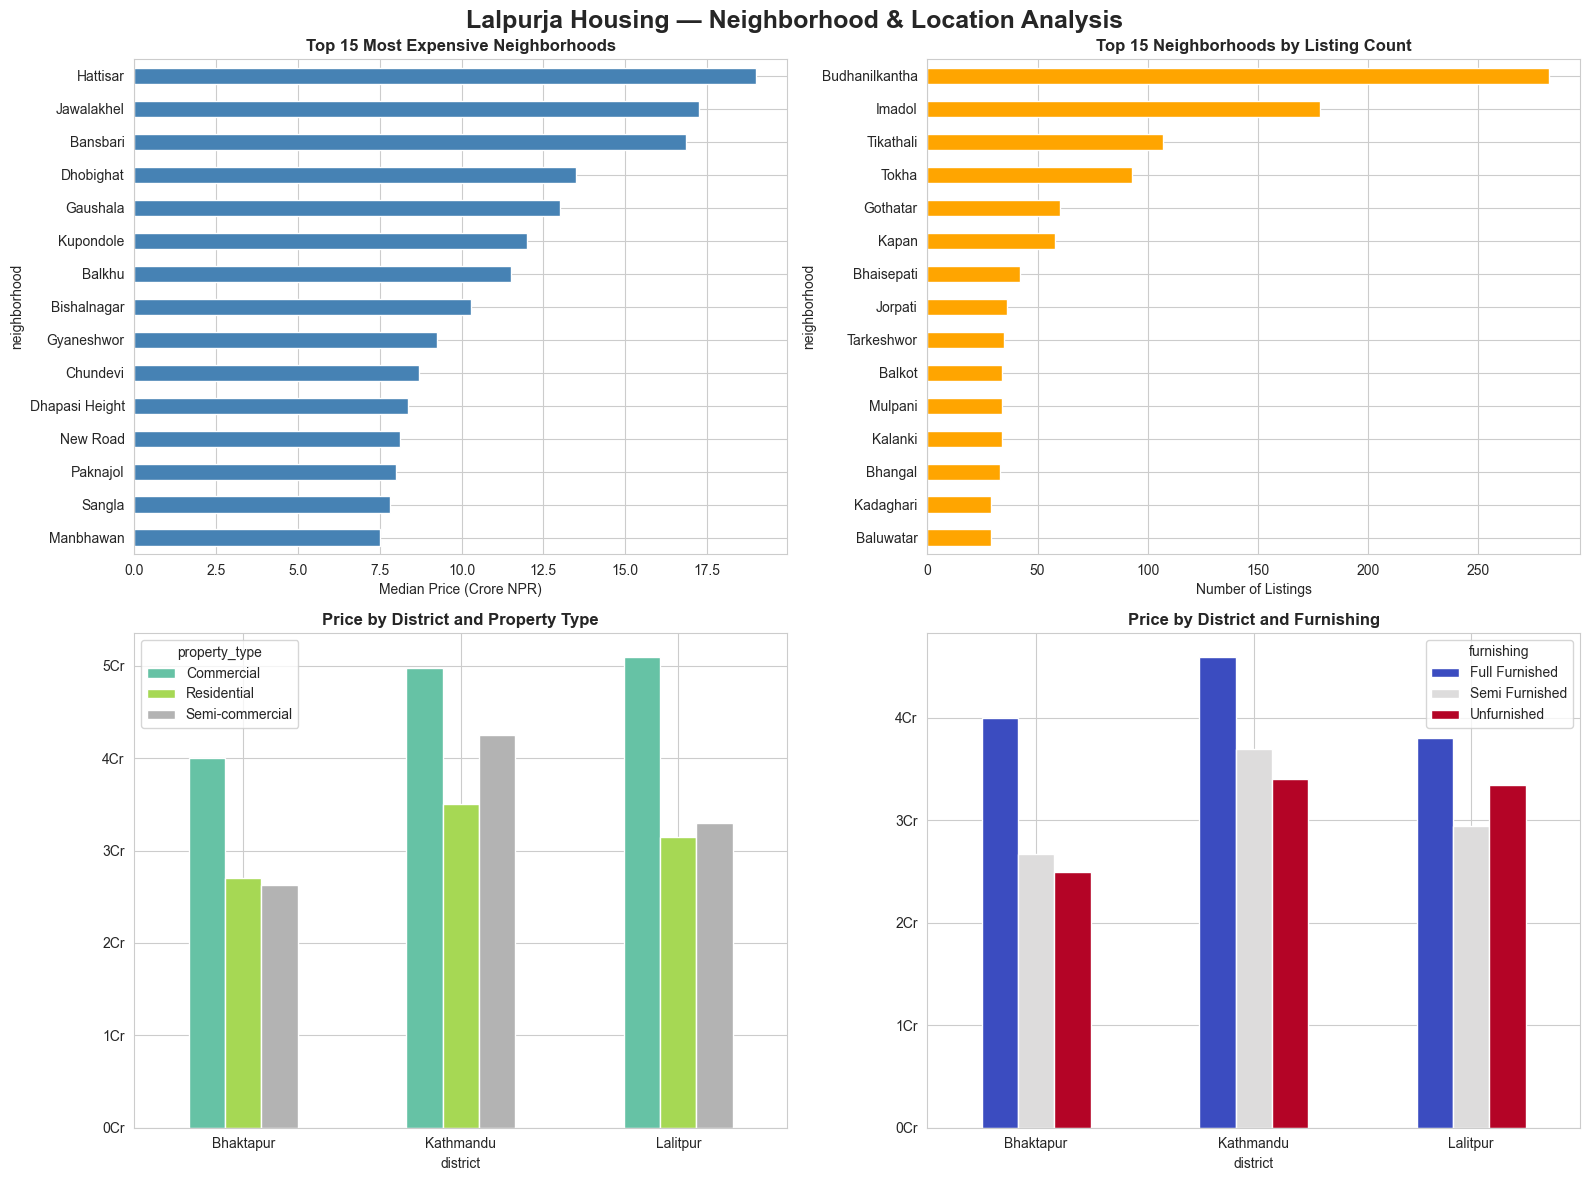

=== Top 15 Most Expensive Neighborhoods ===
neighborhood
Hattisar          190000000.0
Jawalakhel        172500000.0
Bansbari          168750000.0
Dhobighat         135000000.0
Gaushala          130000000.0
Kupondole         120000000.0
Balkhu            115000000.0
Bishalnagar       103000000.0
Gyaneshwor         92500000.0
Chundevi           87000000.0
Dhapasi Height     83500000.0
New Road           81050000.0
Paknajol           80000000.0
Sangla             78000000.0
Manbhawan          75000000.0
Name: total_price, dtype: float64

=== Neighborhood stats ===
Total unique neighborhoods: 181
Neighborhoods with < 3 listings: 43

=== Price by District × Property Type ===
property_type  Commercial  Residential  Semi-commercial
district                                               
Bhaktapur      40000000.0   27000000.0       26250000.0
Kathmandu      49750000.0   35000000.0       42500000.0
Lalitpur       51000000.0   31500000.0       33000000.0


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Lalpurja Housing — Neighborhood & Location Analysis', fontsize=18, fontweight='bold')

# ── Plot 1 — Top 15 most expensive neighborhoods ──────────────────────────
# Fix: sns has no barh → use pandas .plot(kind='barh') instead
top_expensive = (df_lph.groupby('neighborhood')['total_price']
                 .median()
                 .sort_values(ascending=False)
                 .head(15))

(top_expensive / 10_000_000).plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 15 Most Expensive Neighborhoods', fontweight='bold')
axes[0,0].set_xlabel('Median Price (Crore NPR)')
axes[0,0].invert_yaxis()   # Highest at top

# ── Plot 2 — Top 15 most listed neighborhoods ──────────────────────────────
top_n_count = df_lph['neighborhood'].value_counts().head(15)
top_n_count.plot(kind='barh', ax=axes[0,1], color='orange')
axes[0,1].set_title('Top 15 Neighborhoods by Listing Count', fontweight='bold')
axes[0,1].set_xlabel('Number of Listings')
axes[0,1].invert_yaxis()

# ── Plot 3 — Price by District and Property Type ───────────────────────────
df_lph.groupby(['district', 'property_type'])['total_price']\
    .median().unstack().plot(kind='bar', ax=axes[1,0], colormap='Set2')
axes[1,0].set_title('Price by District and Property Type', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10_000_000:.0f}Cr'))

# ── Plot 4 — Price by District and Furnishing ──────────────────────────────
df_lph.groupby(['district', 'furnishing'])['total_price']\
    .median().unstack().plot(kind='bar', ax=axes[1,1], colormap='coolwarm')
axes[1,1].set_title('Price by District and Furnishing', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/10_000_000:.0f}Cr'))

plt.tight_layout()
plt.show()

# ── Key stats ──────────────────────────────────────────────────────────────
print("=== Top 15 Most Expensive Neighborhoods ===")
print(df_lph.groupby('neighborhood')['total_price']
      .median().sort_values(ascending=False).head(15))
print("\n=== Neighborhood stats ===")
print(f"Total unique neighborhoods: {df_lph['neighborhood'].nunique()}")
print(f"Neighborhoods with < 3 listings: {(df_lph['neighborhood'].value_counts() < 3).sum()}")
print("\n=== Price by District × Property Type ===")
print(df_lph.groupby(['district','property_type'])['total_price']
      .median().unstack().round(0))

In [20]:
# ─────────────────────────────────────────
# STEP 6 — NEIGHBORHOOD ZONE CLEANING
# Problem: 43 neighborhoods have < 3 listings
# These rare neighborhoods cause two issues:
# 1. Target encoding unreliable with < 3 samples
# 2. Model can't learn meaningful patterns from 1-2 examples
# Solution: Replace rare neighborhoods with price zones
# Why zones: Preserves price signal without overfitting
# Same 5 zones as lalpurja land dataset for consistency
# ─────────────────────────────────────────

# Step 1 — Check rare neighborhoods and their prices
rare_neighborhoods = df_lph['neighborhood'].value_counts()
rare_neighborhoods = rare_neighborhoods[rare_neighborhoods < 3].index.tolist()

print(f"Rare neighborhoods (<3 listings): {len(rare_neighborhoods)}")
print("\nRare neighborhoods with median price:")
rare_prices = df_lph[df_lph['neighborhood'].isin(rare_neighborhoods)]\
    .groupby('neighborhood')['total_price'].median()\
    .sort_values(ascending=False)
print(rare_prices)

# Step 2 — Assign price zones based on total_price median
# Why these thresholds:
# Based on overall price distribution quartiles
# 75th percentile ≈ 48M → High zone above this
# 50th percentile ≈ 35M → Mid zone around median
# 25th percentile ≈ 26M → Budget zone below this
print("\n=== Price percentiles for zone thresholds ===")
print(df_lph['total_price'].quantile([0.25, 0.50, 0.75, 0.90]))

Rare neighborhoods (<3 listings): 43

Rare neighborhoods with median price:
neighborhood
Hattisar            190000000.0
Jawalakhel          172500000.0
Bansbari            168750000.0
Dhobighat           135000000.0
Gaushala            130000000.0
Chundevi             87000000.0
Dhapasi Height       83500000.0
Paknajol             80000000.0
Sangla               78000000.0
Nakkhu               50000000.0
Bhanimandal          45000000.0
Tarakeshwar          45000000.0
Dahachowk            45000000.0
Greenhill City       45000000.0
Bakhundol            45000000.0
Nepaltar             41000000.0
Tinthana             40000000.0
Kunpondole           39500000.0
Kalikastan           38750000.0
Bohoratar            35000000.0
Mhepi                35000000.0
Patan                34000000.0
Nagarjun             33750000.0
Baghdol              31500000.0
Jagati               29750000.0
Taukhel              29500000.0
Babarmahal           28500000.0
Nakhundol            28000000.0
Halchowk       

In [21]:
# ─────────────────────────────────────────
# ZONE THRESHOLDS based on price percentiles
# Premium_Zone: above 75M  — top 10% luxury
# High_Zone:    48M–75M    — above 75th percentile
# Mid_Zone:     35M–48M    — 50th–75th percentile
# Budget_Zone:  26M–35M    — 25th–50th percentile
# Outskirt_Zone: below 26M — below 25th percentile
#
# Why these thresholds:
# Directly derived from quartiles of actual data
# so each zone represents a meaningful price band
# Example:
#   Hattisar median=190M → Premium_Zone
#   Bohoratar median=35M → Budget_Zone
#   Chapagaun median=14M → Outskirt_Zone
# ─────────────────────────────────────────

def assign_zone(price):
    if price >= 75000000:
        return 'Premium_Zone'
    elif price >= 48000000:
        return 'High_Zone'
    elif price >= 35000000:
        return 'Mid_Zone'
    elif price >= 26000000:
        return 'Budget_Zone'
    else:
        return 'Outskirt_Zone'

# Apply zones to rare neighborhoods
zone_map = {n: assign_zone(p) for n, p in rare_prices.items()}

print("=== Zone assignments ===")
for neighborhood, zone in zone_map.items():
    print(f"  {neighborhood:25s} → {zone}")

# Replace rare neighborhoods with their zones
df_lph['neighborhood'] = df_lph['neighborhood'].apply(
    lambda x: zone_map.get(x, x)  # replace if rare, keep original if not
)

print(f"\n=== After zone cleaning ===")
print(f"Unique neighborhoods: {df_lph['neighborhood'].nunique()}")
print(f"\nZone distribution:")
zone_counts = df_lph['neighborhood'].value_counts()
print(zone_counts[zone_counts.index.str.contains('Zone')])

print(f"\nAll neighborhoods remaining:")
print(df_lph['neighborhood'].value_counts().to_string())

=== Zone assignments ===
  Hattisar                  → Premium_Zone
  Jawalakhel                → Premium_Zone
  Bansbari                  → Premium_Zone
  Dhobighat                 → Premium_Zone
  Gaushala                  → Premium_Zone
  Chundevi                  → Premium_Zone
  Dhapasi Height            → Premium_Zone
  Paknajol                  → Premium_Zone
  Sangla                    → Premium_Zone
  Nakkhu                    → High_Zone
  Bhanimandal               → Mid_Zone
  Tarakeshwar               → Mid_Zone
  Dahachowk                 → Mid_Zone
  Greenhill City            → Mid_Zone
  Bakhundol                 → Mid_Zone
  Nepaltar                  → Mid_Zone
  Tinthana                  → Mid_Zone
  Kunpondole                → Mid_Zone
  Kalikastan                → Mid_Zone
  Bohoratar                 → Mid_Zone
  Mhepi                     → Mid_Zone
  Patan                     → Budget_Zone
  Nagarjun                  → Budget_Zone
  Baghdol                   → Budge

In [22]:
# ─────────────────────────────────────────
# FIX High_Zone — only 1 listing
# Nakkhu median=50M sits between High and Mid zone
# Merge into Mid_Zone since it's closer to Mid threshold (48M)
# and 1 listing is too few to be meaningful even as a zone
# ─────────────────────────────────────────
df_lph['neighborhood'] = df_lph['neighborhood'].replace('High_Zone', 'Mid_Zone')
print(f"High_Zone merged into Mid_Zone")
print(f"Unique neighborhoods: {df_lph['neighborhood'].nunique()}")
print(f"\nZone distribution:")
print(df_lph['neighborhood'].value_counts()[
    df_lph['neighborhood'].value_counts().index.str.contains('Zone')])

# ─────────────────────────────────────────
# MUNICIPALITY STANDARDIZATION
# Same issue as lalpurja land — 100+ spelling variations
# Check what we have first
# ─────────────────────────────────────────
print(f"\n=== Municipality distribution ===")
print(f"Unique municipalities: {df_lph['municipality'].nunique()}")
print(df_lph['municipality'].value_counts().to_string())

High_Zone merged into Mid_Zone
Unique neighborhoods: 142

Zone distribution:
neighborhood
Outskirt_Zone    21
Mid_Zone         14
Premium_Zone     14
Budget_Zone      13
Name: count, dtype: int64

=== Municipality distribution ===
Unique municipalities: 120
municipality
Kathmandu                           519
Budhanilkantha                      292
Mahalaxmi                           256
Lalitpur                            189
Tokha                               119
Kageshwori Manohara                 103
Suryabinayak                         82
Nagarjun                             68
Budanilkantha                        60
Madhyapur Thimi                      51
Tarkeshwor                           32
Budhanilkanta                        25
Budhanilakantha                      24
mahalaxmi                            23
Gokarneswor                          22
Godawari                             22
Chandragiri                          21
Changunarayan                        20
Gokarnesh

In [25]:
# ─────────────────────────────────────────
# MUNICIPALITY STANDARDIZATION
# 120 variations → ~15 clean municipalities
# Same approach as lalpurja land dataset
# Group all spelling variations under one canonical name
# ─────────────────────────────────────────

municipality_map = {
    # ── KATHMANDU ──────────────────────────────────────────
    'Kathmandu':                            'Kathmandu',
    'KMC':                                  'Kathmandu',
    'Kmc':                                  'Kathmandu',
    'Kathmandu Metropolitan':               'Kathmandu',
    'Kathmandu metropolitan':               'Kathmandu',
    'Kathmandu Metropolitan City':          'Kathmandu',
    'Kathmandu Metropolitan city':          'Kathmandu',
    'Kathmandu mahanagar':                  'Kathmandu',
    'Kathamandu':                           'Kathmandu',
    'kathmandu':                            'Kathmandu',
    'kathmandu metropolitan':               'Kathmandu',
    'karhmandu':                            'Kathmandu',
    'Kathmy':                               'Kathmandu',

    # ── BUDHANILKANTHA ─────────────────────────────────────
    'Budhanilkantha':                       'Budhanilkantha',
    'Budanilkantha':                        'Budhanilkantha',
    'Budhanilkanta':                        'Budhanilkantha',
    'Budhanilakantha':                      'Budhanilkantha',
    'budhanilkantha':                       'Budhanilkantha',
    'budhanilkanta':                        'Budhanilkantha',
    'Budhanilktha':                         'Budhanilkantha',
    'Budhanilkatha':                        'Budhanilkantha',
    'Budhanikatha':                         'Budhanilkantha',
    'Budhaknilkantha':                      'Budhanilkantha',
    'Budhanilkntha':                        'Budhanilkantha',
    'Bhudhanilkatha':                       'Budhanilkantha',
    'Bidanilkantha':                        'Budhanilkantha',
    'Budanilkntha':                         'Budhanilkantha',
    'Budanilknntha':                        'Budhanilkantha',
    'Budanillantha':                        'Budhanilkantha',
    'Budhanilkantha Nagarpalika':           'Budhanilkantha',
    'Budhanilkantha Mahanagarpalika':       'Budhanilkantha',
    'Budhanilkantha Maha Nagarpalika':      'Budhanilkantha',

    # ── MAHALAXMI ──────────────────────────────────────────
    'Mahalaxmi':                            'Mahalaxmi',
    'mahalaxmi':                            'Mahalaxmi',
    'Mahalaxmi Muncipality':                'Mahalaxmi',
    'Mahalakxmi':                           'Mahalaxmi',
    'Mahalakshmi':                          'Mahalaxmi',
    'Mahalaxmisthan':                       'Mahalaxmi',

    # ── LALITPUR ───────────────────────────────────────────
    'Lalitpur':                             'Lalitpur',
    'lalitpur':                             'Lalitpur',
    'LMC':                                  'Lalitpur',
    'Lalitpur MPC':                         'Lalitpur',
    'Lalitpur Metropolitan City':           'Lalitpur',
    'Lalitpur mahanagapalika':              'Lalitpur',
    'Metropolitan Lalitpur':                'Lalitpur',
    'Lalpitpur':                            'Lalitpur',
    'Laly':                                 'Lalitpur',
    'jhamsikhel':                           'Lalitpur',
    'Dholahiti':                            'Lalitpur',
    'Kusunti':                              'Lalitpur',
    'Bhaisepati':                           'Lalitpur',
    'Sainbu':                               'Lalitpur',

    # ── TOKHA ──────────────────────────────────────────────
    'Tokha':                                'Tokha',
    'Tokha Nagarpalika':                    'Tokha',
    'Tokha Municipality':                   'Tokha',
    'Thankot':                              'Tokha',

    # ── KAGESHWORI MANOHARA ────────────────────────────────
    'Kageshwori Manohara':                  'Kageshwori Manohara',
    'Kageswori Manohara':                   'Kageshwori Manohara',
    'Kageshwori Manahora':                  'Kageshwori Manohara',
    'Kageshwori Monahara':                  'Kageshwori Manohara',
    'Kageshwori Monahora':                  'Kageshwori Manohara',
    'Kageshwori Manohar':                   'Kageshwori Manohara',
    'Kageshwori Manohora':                  'Kageshwori Manohara',
    'Kageshwari Manohara':                  'Kageshwori Manohara',
    'Kageshwari-Manohara':                  'Kageshwori Manohara',
    'Kageshwori, Manohara':                 'Kageshwori Manohara',
    'Kagashwori Manohara':                  'Kageshwori Manohara',
    'Kagaeshwori Manahora':                 'Kageshwori Manohara',
    'kageswori manohara':                   'Kageshwori Manohara',
    'Kageswori manohara':                   'Kageshwori Manohara',
    'Kageshwori Manahara Municipality':     'Kageshwori Manohara',
    'Kageshowri Manohara':                  'Kageshwori Manohara',
    'Kageshwori Mohanara':                  'Kageshwori Manohara',

    # ── SURYABINAYAK ───────────────────────────────────────
    'Suryabinayak':                         'Suryabinayak',
    'Suryavinayak':                         'Suryabinayak',
    'Suryabinyak':                          'Suryabinayak',
    'Suryabinak':                           'Suryabinayak',
    'Suryabnayak':                          'Suryabinayak',
    'suryabinayak':                         'Suryabinayak',
    'Suryabinayak Municipality':            'Suryabinayak',
    'Suryabinayak Na. pa.':                 'Suryabinayak',
    'Suryabinayak Na. Pa.':                 'Suryabinayak',
    'Suryabinayak Nagarpalika':             'Suryabinayak',

    # ── NAGARJUN ───────────────────────────────────────────
    'Nagarjun':                             'Nagarjun',
    'Nagargun':                             'Nagarjun',
    'Nagarjun Nagarpalika':                 'Nagarjun',
    'Ramkot':                               'Nagarjun',
    'Baluwakhani':                          'Nagarjun',
    'Balambu':                              'Nagarjun',
    'kalanki':                              'Nagarjun',
    'Syuchatar':                            'Nagarjun',

    # ── MADHYAPUR THIMI ────────────────────────────────────
    'Madhyapur Thimi':                      'Madhyapur Thimi',
    'Madhyapur Thimi Municipality':         'Madhyapur Thimi',
    'Madyapur Thimi':                       'Madhyapur Thimi',
    'Madhyapur':                            'Madhyapur Thimi',
    'Tikathali':                            'Madhyapur Thimi',
    'Balkot':                               'Madhyapur Thimi',

    # ── GOKARNESHWOR ───────────────────────────────────────
    'Gokarneswor':                          'Gokarneshwor',
    'Gokarneshwor':                         'Gokarneshwor',
    'Gokarneshwar':                         'Gokarneshwor',
    'Gokarnashwor':                         'Gokarneshwor',
    'Gokenshowr':                           'Gokarneshwor',
    'gokarneswor':                          'Gokarneshwor',
    'Boudha':                               'Gokarneshwor',
    'Baneshwor':                            'Gokarneshwor',

    # ── TARKESHWOR ─────────────────────────────────────────
    'Tarkeshwor':                           'Tarkeshwor',
    'Tarkeshwor Municipality':              'Tarkeshwor',
    'Tarkeshwor Nagarpalika':               'Tarkeshwor',
    'Tarkeshwar':                           'Tarkeshwor',
    'Tarakeshwar municipality':             'Tarkeshwor',
    'tarkeshwor municipality':              'Tarkeshwor',

    # ── GODAWARI ───────────────────────────────────────────
    'Godawari':                             'Godawari',
    'godawari':                             'Godawari',

    # ── CHANDRAGIRI ────────────────────────────────────────
    'Chandragiri':                          'Chandragiri',
    'chandragiri':                          'Chandragiri',

    # ── CHANGUNARAYAN ──────────────────────────────────────
    'Changunarayan':                        'Changunarayan',

    # ── KIRTIPUR ───────────────────────────────────────────
    'Kirtipur':                             'Kirtipur',
    'kirtipur':                             'Kirtipur',
    'Kritipur':                             'Kirtipur',

    # ── BHAKTAPUR ──────────────────────────────────────────
    'Bhaktapur':                            'Bhaktapur',
}

# Apply mapping
df_lph['municipality'] = df_lph['municipality'].replace(municipality_map)

# Check remaining unmapped
unmapped = df_lph[~df_lph['municipality'].isin(municipality_map.values())]['municipality'].value_counts()
print(f"=== Unmapped municipalities ===")
print(unmapped if len(unmapped) > 0 else "✅ All municipalities mapped")

print(f"\n=== After standardization ===")
print(f"Unique municipalities: {df_lph['municipality'].nunique()}")
print(df_lph['municipality'].value_counts().to_string())

=== Unmapped municipalities ===
✅ All municipalities mapped

=== After standardization ===
Unique municipalities: 16
municipality
Kathmandu              561
Budhanilkantha         431
Mahalaxmi              288
Lalitpur               213
Kageshwori Manohara    151
Tokha                  131
Suryabinayak            95
Nagarjun                77
Madhyapur Thimi         58
Gokarneshwor            55
Tarkeshwor              45
Godawari                23
Chandragiri             22
Changunarayan           20
Kirtipur                17
Bhaktapur                3


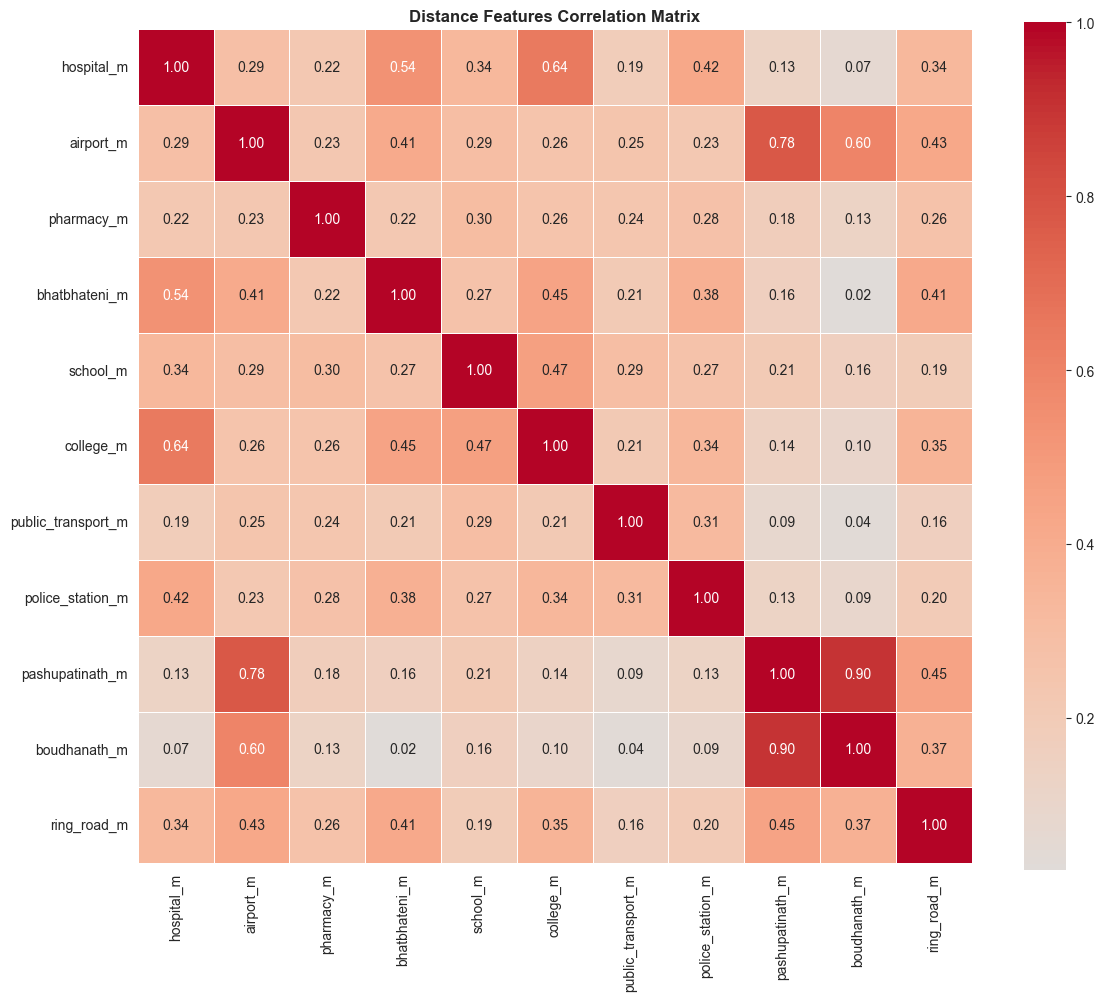

=== High correlations (>0.7) ===
airport_m ↔ pashupatinath_m: 0.777
pashupatinath_m ↔ boudhanath_m: 0.904

=== Final dataset shape ===
Rows: 2190
Columns: 30
Unique neighborhoods: 142
Unique municipalities: 16
Nulls: 84


In [26]:
# ─────────────────────────────────────────
# FINAL EDA — CORRELATION MATRIX
# Check multicollinearity between distance columns
# Same check we did for lalpurja land
# ─────────────────────────────────────────
dist_cols = ['hospital_m', 'airport_m', 'pharmacy_m', 'bhatbhateni_m',
             'school_m', 'college_m', 'public_transport_m', 'police_station_m',
             'pashupatinath_m', 'boudhanath_m', 'ring_road_m']

corr_matrix = df_lph[dist_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Distance Features Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# Check high correlations
print("=== High correlations (>0.7) ===")
for i in range(len(dist_cols)):
    for j in range(i+1, len(dist_cols)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.7:
            print(f"{dist_cols[i]} ↔ {dist_cols[j]}: {corr:.3f}")

print("\n=== Final dataset shape ===")
print(f"Rows: {len(df_lph)}")
print(f"Columns: {df_lph.shape[1]}")
print(f"Unique neighborhoods: {df_lph['neighborhood'].nunique()}")
print(f"Unique municipalities: {df_lph['municipality'].nunique()}")
print(f"Nulls: {df_lph.isnull().sum().sum()}")

In [33]:
# ─────────────────────────────────────────
# CHECK NULLS — appeared after zone cleaning
# ─────────────────────────────────────────
print("=== Where are the 84 nulls? ===")
nulls = df_lph.isnull().sum()
print(nulls[nulls > 0])

# ─────────────────────────────────────────
# HANDLE MULTICOLLINEARITY
# airport_m ↔ pashupatinath_m: 0.78
# pashupatinath_m ↔ boudhanath_m: 0.904
# Drop pashupatinath_m — it's highly correlated
# with BOTH airport_m and boudhanath_m
# Keep airport_m (stronger price correlation -0.096)
# Keep boudhanath_m (strong price correlation -0.164)
# Why: Keeping correlated features causes model to
# double-count the same information which adds noise
# Example: If pashupatinath_m=5000 tells us airport_m≈6000
# then having both adds no new information
# ─────────────────────────────────────────
df_lph.drop(columns=['pashupatinath_m'], inplace=True)
print(f"\n✅ Dropped pashupatinath_m (correlated with both airport_m and boudhanath_m)")
print(f"Remaining distance columns: {[c for c in df_lph.columns if '_m' in c]}")

=== Where are the 84 nulls? ===
age_bin    84
dtype: int64

✅ Dropped pashupatinath_m (correlated with both airport_m and boudhanath_m)
Remaining distance columns: ['hospital_m', 'airport_m', 'pharmacy_m', 'bhatbhateni_m', 'school_m', 'college_m', 'public_transport_m', 'police_station_m', 'boudhanath_m', 'ring_road_m']


In [35]:
df_lph.sample(4)

,district,property_type,property_face,road_type,negotiable,furnishing,property_area,date_posted,views,municipality,ward_no,neighborhood,total_price,land_size_aana,built_up_sqft,house_age,road_width_feet,hospital_m,airport_m,pharmacy_m,bhatbhateni_m,school_m,college_m,public_transport_m,police_station_m,boudhanath_m,ring_road_m,age_bin,size_bin
616,Kathmandu,Residential,East,Low Access,Yes,Semi Furnished,9 Aana,2025 April 4,380.0,Budhanilkantha,3.0,Budhanilkantha,70000000.0,9.0,1369.000,2.0,20.0,800.0,10000.0,500.0,4000.0,200.0,500.0,500.0,500.0,8000.0,3000.0,0-2yr,medium
102,Kathmandu,Residential,East,High Access,Yes,Full Furnished,6 Aana,2025 August 24,402.0,Kathmandu,6.0,Boudha,50000000.0,6.0,2738.000,11.0,14.0,1000.0,7000.0,500.0,2000.0,200.0,700.0,400.0,400.0,1000.0,1300.0,11-20yr,large
1103,Kathmandu,Residential,North,High Access,Yes,Unfurnished,3 Aana,2024 November 24,346.0,Kathmandu,7.0,Chabahil,18000000.0,3.0,1026.750,15.0,8.0,1040.0,4000.0,380.0,3000.0,320.0,840.0,500.0,424.0,2000.0,500.0,11-20yr,small
1730,Lalitpur,Residential,East,High Access,Yes,Semi Furnished,4 Aana,2025 March 3,291.0,Mahalaxmi,6.0,Outskirt_Zone,27000000.0,4.0,1197.875,2.0,16.0,600.0,5000.0,50.0,300.0,200.0,300.0,80.0,300.0,12000.0,5000.0,0-2yr,small


In [36]:
# ─────────────────────────────────────────
# DROP age_bin — helper column created during
# built_up_sqft grouped median imputation
# Not needed for modeling — just a temporary bin
# ─────────────────────────────────────────
df_lph.drop(columns=['age_bin'], inplace=True)

print(f"✅ Dropped age_bin")
print(f"Nulls: {df_lph.isnull().sum().sum()}")
print(f"Shape: {df_lph.shape}")
print(f"Columns: {list(df_lph.columns)}")

✅ Dropped age_bin
Nulls: 0
Shape: (2190, 28)
Columns: ['district', 'property_type', 'property_face', 'road_type', 'negotiable', 'furnishing', 'property_area', 'date_posted', 'views', 'municipality', 'ward_no', 'neighborhood', 'total_price', 'land_size_aana', 'built_up_sqft', 'house_age', 'road_width_feet', 'hospital_m', 'airport_m', 'pharmacy_m', 'bhatbhateni_m', 'school_m', 'college_m', 'public_transport_m', 'police_station_m', 'boudhanath_m', 'ring_road_m', 'size_bin']


In [37]:
# ─────────────────────────────────────────
# DROP remaining helper columns
# size_bin — temporary bin created during
# built_up_sqft grouped median imputation
# property_area — raw string, already parsed into land_size_aana
# date_posted — listing date, not useful for price prediction
# views — near zero correlation confirmed in lalpurja land EDA
# negotiable — 98.4% are Yes, no signal
# ─────────────────────────────────────────
drop_helpers = ['size_bin', 'property_area', 'date_posted', 'views', 'negotiable']
df_lph.drop(columns=drop_helpers, inplace=True)

print(f"✅ Dropped helper columns: {drop_helpers}")
print(f"Nulls: {df_lph.isnull().sum().sum()}")
print(f"Shape: {df_lph.shape}")
print(f"\nFinal columns: {list(df_lph.columns)}")

# ─────────────────────────────────────────
# SAVE CLEANED EDA FILE
# ─────────────────────────────────────────
df_lph.to_csv('cleaned_lalpurja_house_after_eda.csv', index=False)
print(f"\n✅ Saved cleaned_lalpurja_house_after_eda.csv")

✅ Dropped helper columns: ['size_bin', 'property_area', 'date_posted', 'views', 'negotiable']
Nulls: 0
Shape: (2190, 23)

Final columns: ['district', 'property_type', 'property_face', 'road_type', 'furnishing', 'municipality', 'ward_no', 'neighborhood', 'total_price', 'land_size_aana', 'built_up_sqft', 'house_age', 'road_width_feet', 'hospital_m', 'airport_m', 'pharmacy_m', 'bhatbhateni_m', 'school_m', 'college_m', 'public_transport_m', 'police_station_m', 'boudhanath_m', 'ring_road_m']

✅ Saved cleaned_lalpurja_house_after_eda.csv
